In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [3]:
path = "data/StudentPerformanceFactors.csv"
df = pd.read_csv(path, sep=',', encoding='ISO-8859-1')

engine = create_engine("sqlite:///data/students.sqlite")
df.to_sql("students", engine, index=False, if_exists="replace")

6607

In [4]:
path_salary = "data/salary/Salary_Data.csv"
s_df = pd.read_csv(path_salary, sep=',', encoding='ISO-8859-1')

engine2 = create_engine("sqlite:///data/salary.sqlite")
s_df = s_df.rename(columns={"ï»¿Age": "Age", "Education Level":"Education_Level",
                            "Job_Title":"Job", "Years of Experience":"Years_of_Experience"})

s_df.to_sql("salary", engine2, index=False, if_exists="replace")


6704

### Students motivation distribution
This pie chart shows the distribution of students by motivation level.
Each slice represents a different motivation category (Low, Medium, or High), with the percentage displayed directly on the chart.

This is an easy way to visualize how the current relationship between students and their studies is going.

Text(0.5, 1.0, 'Students motivation distribution')

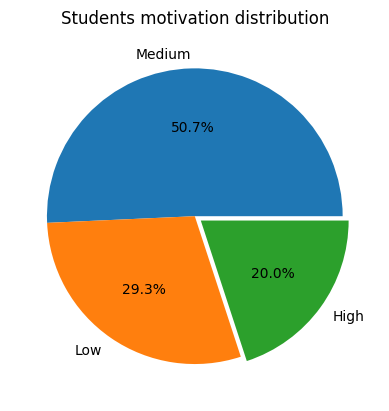

In [5]:
students = df['Motivation_Level'].value_counts()
plt.pie(students, labels=students.index, autopct='%1.1f%%', explode=(0.0, 0.0, 0.05))
plt.title("Students motivation distribution")

### Average Salaries by Years of Experience

The line chart below illustrates the average salary based on years of experience.
The x-axis represents years of professional experience and the y-axis shows the corresponding average salary in dollars.

It helps visualize how experience impacts income. The increase in the income following the years of experience was expected.

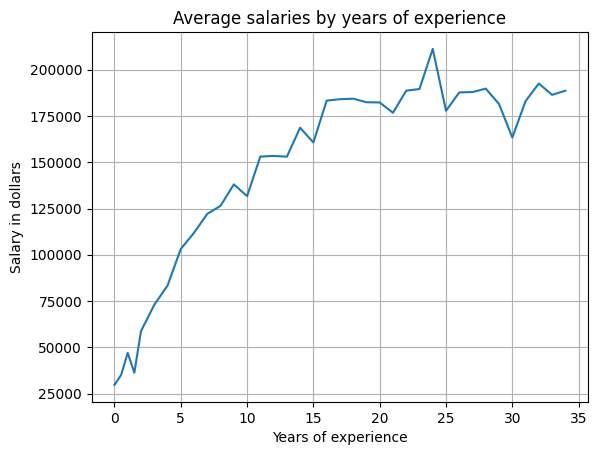

In [6]:
experience = s_df.groupby(['Years_of_Experience'])['Salary'].mean()
plt.plot(experience.index, experience.values)
plt.title("Average salaries by years of experience")
plt.ylabel("Salary in dollars")
plt.xlabel("Years of experience")
plt.grid(True)

### Number of People per Education Level

This graphic shows the number of people per education level, using data from the salary dataset.
Each bar corresponds to one level of education, and the numbers above the bars indicate the count of individuals in each category.

This visualization highlights how education is distributed across the dataset, helping to identify which education levels are most common in the studied sample.

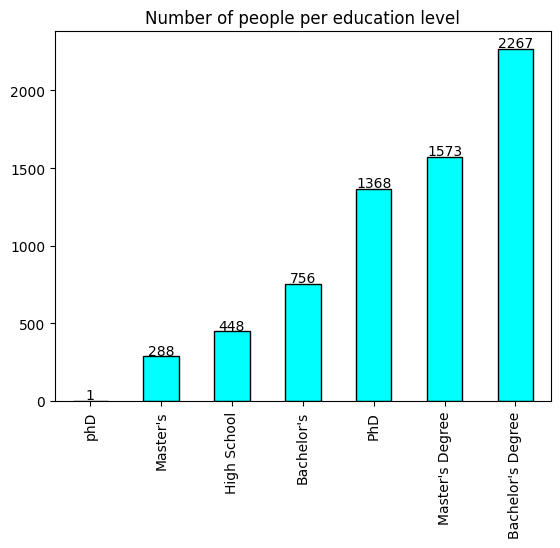

In [26]:
education = s_df['Education_Level'].value_counts()
education = education.sort_values(ascending=True)
graphic = education.plot(kind='bar', edgecolor='black', title="Number of people per education level", 
                        xlabel='', color='cyan')

for i, v in enumerate(education.values):
    graphic.text(i, v + 10, str(v), ha='center')